In [14]:
from PIL import Image

In [15]:
import numpy as np

In [30]:
import importlib
import image_builder
importlib.reload(image_builder)

<module 'image_builder' from '/Users/anthonyliu/Projects/receipt-printer-exquisite-corpse/src/image_builder.py'>

# Load content

In [17]:
import sqlite3
import db
import form_parser

In [18]:
conn = sqlite3.connect('../test.db')

In [19]:
db_img_bytes = db.get_drawing(conn, 11)[4]

In [20]:
db_img = Image.frombuffer("RGB", (512, 512), db_img_bytes)

In [21]:
drawing_area = 200
border_width = 3
marker_space = 4
marker_size = 144

total_margin = border_width + marker_space
total_width = drawing_area + 2 * total_margin

In [22]:
resized_img = (
    db_img
        .resize((total_width, total_width))
        .crop([
            total_margin,
            total_margin,
            total_width - total_margin,
            total_width - total_margin,
        ])
        .convert(mode='L')
)

In [23]:
np.array(resized_img)

array([[ 70, 122, 171, ..., 165, 167, 186],
       [ 69, 151, 200, ..., 228, 226, 214],
       [ 70, 148, 190, ..., 226, 225, 210],
       ...,
       [135, 192, 186, ..., 179, 182, 177],
       [130, 194, 186, ..., 179, 182, 172],
       [133, 194, 190, ..., 184, 185, 165]], shape=(200, 200), dtype=uint8)

# Forms

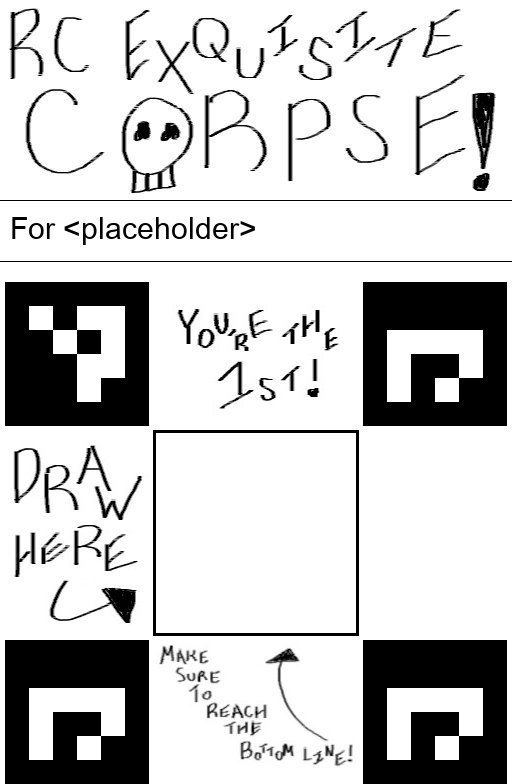

In [36]:
form_01 = image_builder.build_start_form((1, 1, 1), "<placeholder>")
Image.fromarray(form_01)

In [37]:
form_02 = image_builder.build_middle_form((1, 1, 1), "<placeholder>", np.array(resized_img))
z = Image.fromarray(form_02)
z.save('./test_02.jpg')

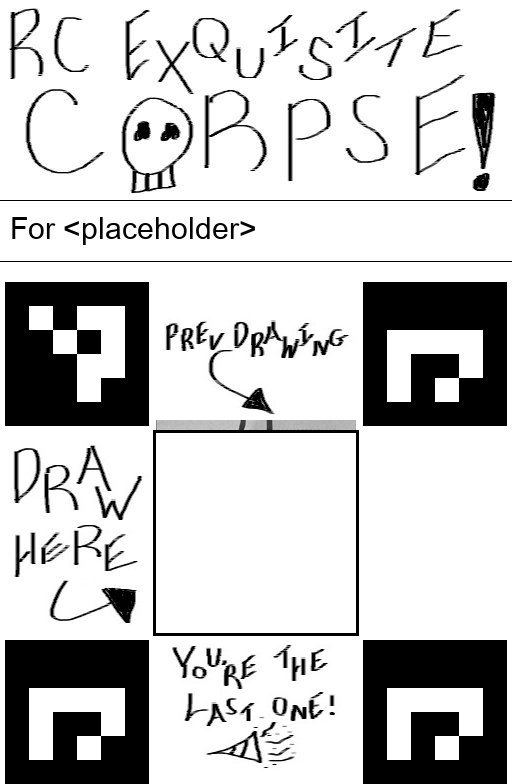

In [38]:
form_03 = image_builder.build_final_form((1, 1, 1), "<placeholder>", np.array(resized_img))
Image.fromarray(form_03)